In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [8]:
REPR = 'spectrum'
ALPHA = 0.4

colors = {
    'magnitude': '#DE0A00',
    'cosine_similarity': '#D0DF00',
    'distances': '#0075DE'
}

df = pd.read_csv(f'{REPR}-correlations.csv')
df_abs = df.abs()

# Plot function to visualize the results


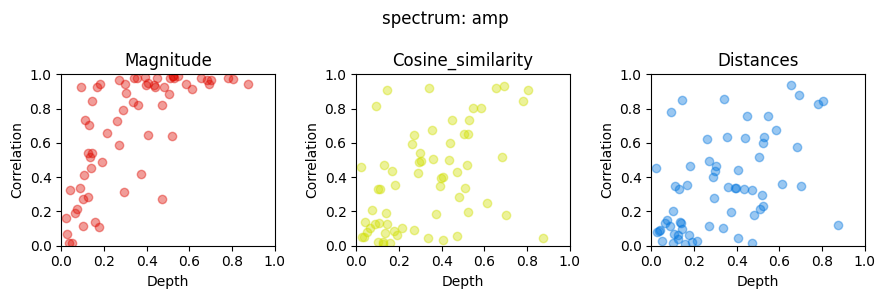

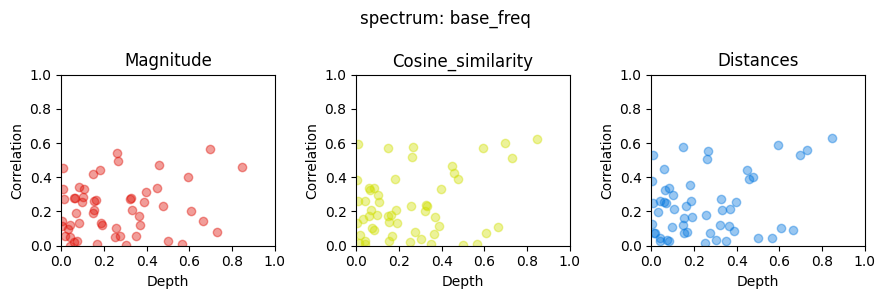

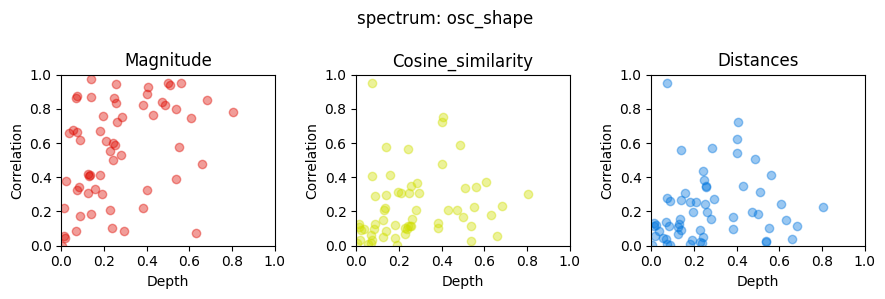

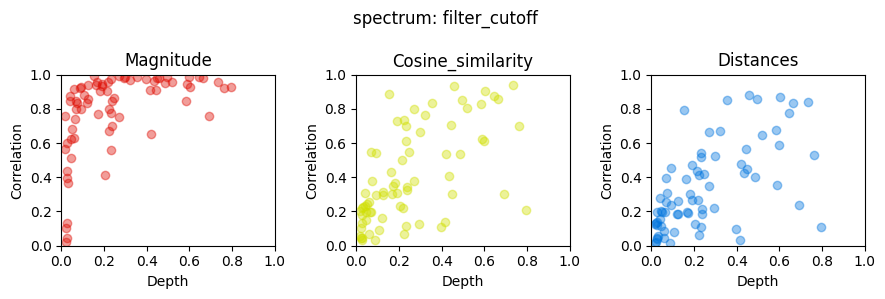

In [9]:

def plot_metric_correlation_scatter(ax, df, param="amp"):
    colors_list = list(colors.values())
    metrics = ['magnitude', 'cosine_similarity', 'distances']

    for i, metric in enumerate(metrics):
        ax[i].plot(df[f"{param}_depth"], df[f"{metric}_{param}"], 'o', color=colors_list[i], label=metric.capitalize(), alpha=ALPHA)
        ax[i].set_title(f"{metric.capitalize()}")
        ax[i].set_xlim(0, 1.0)
        ax[i].set_ylim(0, 1.0)
        ax[i].set_xlabel("Depth")
        ax[i].set_ylabel("Correlation")

def create_plot_grid(df, ranges ,param="'amp"):
    fig, axes = plt.subplots(1,3, figsize=(9, 3))
    fig.suptitle(f'{REPR}: {param}', fontsize=12)
    
    for i, (start, end) in enumerate(ranges):
        plot_metric_correlation_scatter(
            axes, 
            df.iloc[start:end], 
            param=param, 
        )
    
    plt.tight_layout()
    plt.show()


create_plot_grid(df_abs, ranges=[(0,250)], param="amp")
create_plot_grid(df_abs, ranges=[(0,250)], param="base_freq")
create_plot_grid(df_abs, ranges=[(0,250)], param="osc_shape")
create_plot_grid(df_abs, ranges=[(0,250)], param="filter_cutoff")

In [10]:
import itertools

params = 'amp base_freq filter_cutoff osc_shape'.split()
combinations_2 = list(itertools.combinations(params, 2))
combinations_3 = list(itertools.combinations(params, 3))

print(combinations_2[0][1])


base_freq


In [11]:

best_metrics = {
    'mfcc': {'amp':'magnitude', 
             'base_freq':'distances', 
             'osc_shape':'magnitude', 
             'filter_cutoff':'magnitude'
            },
    'cqt': {'amp':'magnitude',
            'base_freq':'magnitude',
            'osc_shape':'magnitude',
            'filter_cutoff':'magnitude'
            },
    "music2latent": {'amp':'distances', 
                     'base_freq':'magnitude', 
                     'osc_shape':'distances', 
                     'filter_cutoff':'magnitude'
                     },
    'dac': {'amp':'distances',
            'base_freq':'magnitude',
            'osc_shape':'distances',
            'filter_cutoff':'magnitude'        
            },
    'spectrum': {'amp':'magnitude', 
                 'base_freq':'distances', 
                 'osc_shape':'magnitude', 
                 'filter_cutoff':'magnitude'
    }    
}

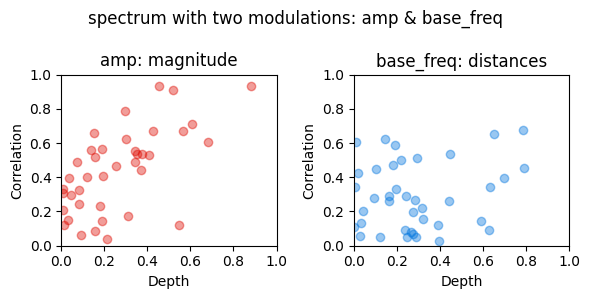

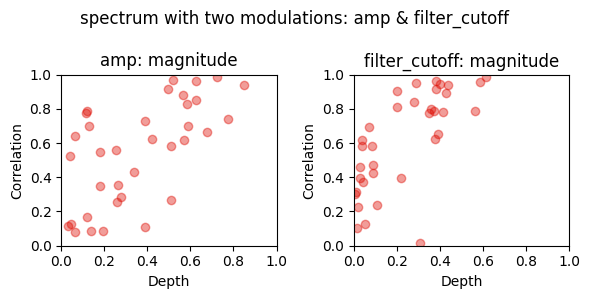

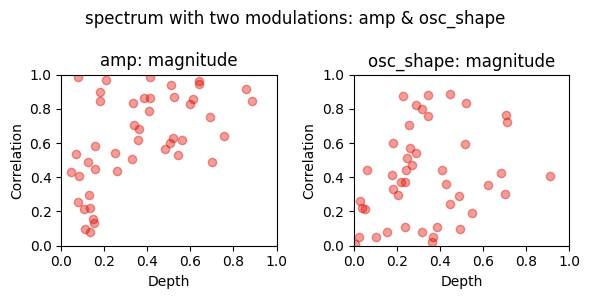

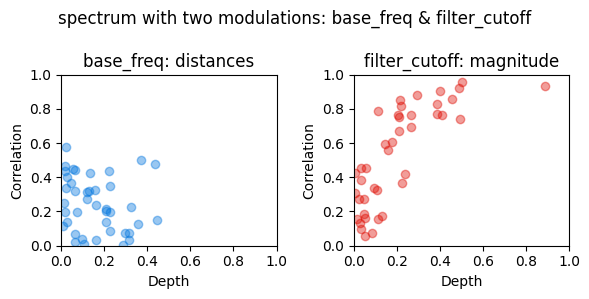

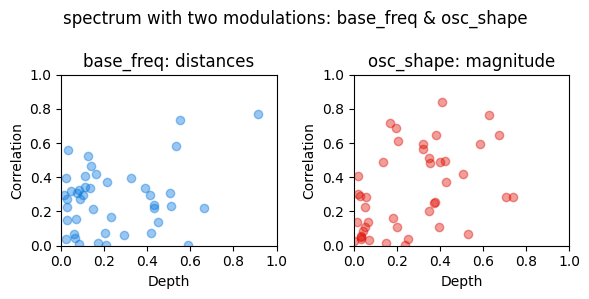

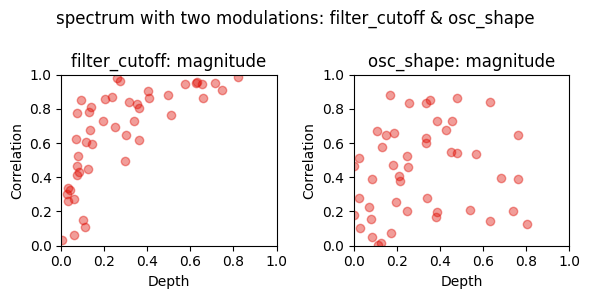

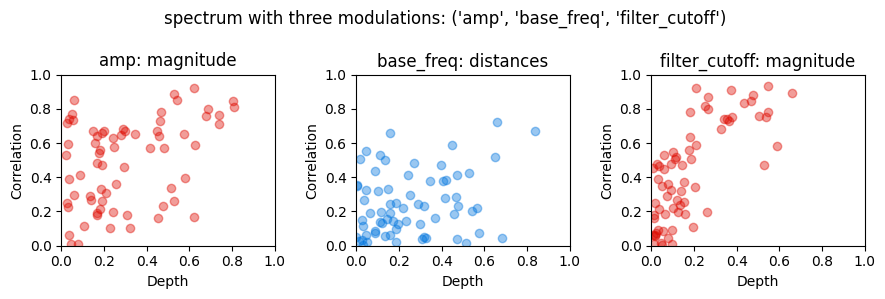

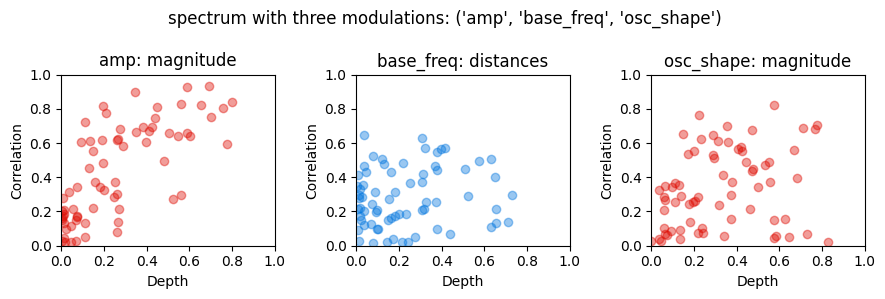

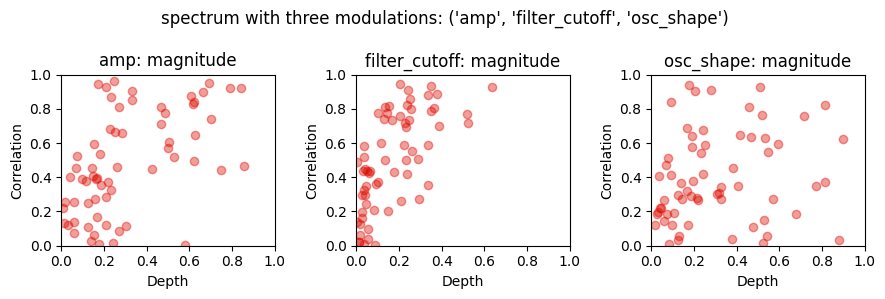

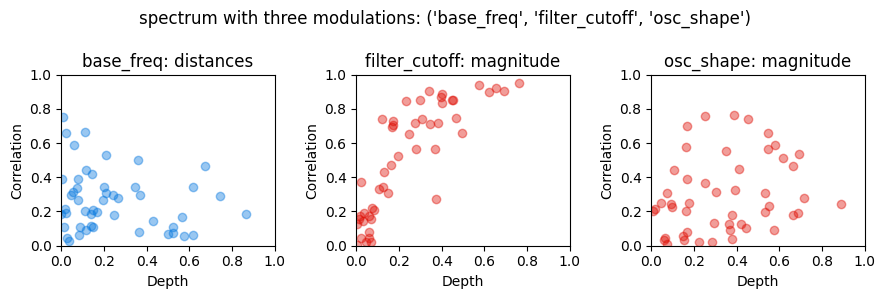

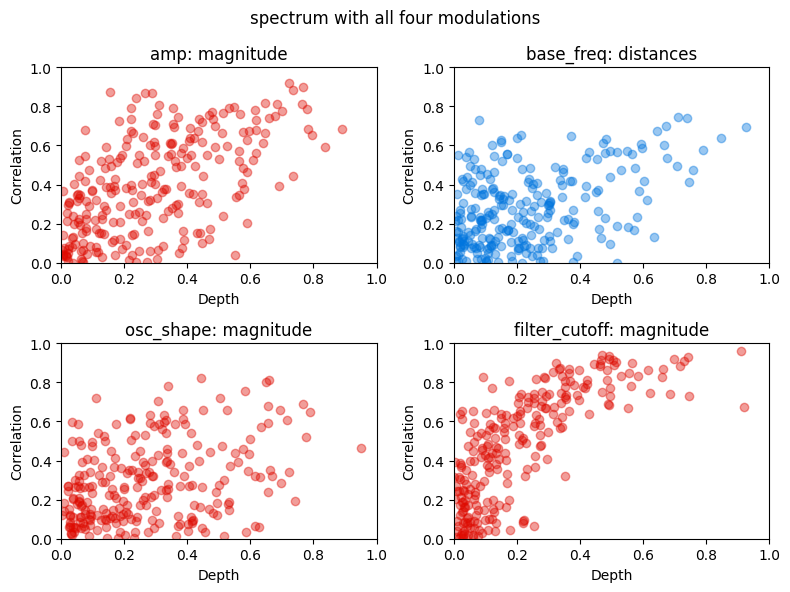

In [12]:
colors = {
    'magnitude': '#DE0A00',
    'cosine_similarity': '#D0DF00',
    'distances': '#0075DE'
}

def plot_couple(df, couple, best_metrics_repr, colors = colors):
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    fig.suptitle(f'{REPR} with two modulations: {couple[0]} & {couple[1]}', fontsize=12)

    for i, param in enumerate(couple):
        ax[i].plot(df[f"{param}_depth"], df[f"{best_metrics_repr[param]}_{param}"], "o", 
                   color=colors[best_metrics_repr[param]], alpha= ALPHA)
        ax[i].set_xlim(0, 1.0)
        ax[i].set_ylim(0, 1.0)
        ax[i].set_xlabel("Depth")
        ax[i].set_ylabel("Correlation")
        ax[i].set_title(f'{param}: {best_metrics_repr[param]}')
    plt.tight_layout()
    plt.show()

def plot_triplet(df, triplet, best_metrics_repr, colors = colors):
    fig, ax = plt.subplots(1, 3, figsize=(9, 3))
    plt.suptitle(f'{REPR} with three modulations: {triplet}', fontsize=12)

    for i, param in enumerate(triplet):
        ax[i].plot(df[f"{param}_depth"], df[f"{best_metrics_repr[param]}_{param}"], "o", 
                   color=colors[best_metrics_repr[param]], alpha=ALPHA)
        ax[i].set_xlim(0, 1.0)
        ax[i].set_ylim(0, 1.0)
        ax[i].set_xlabel("Depth")
        ax[i].set_ylabel("Correlation")
        ax[i].set_title(f'{param}: {best_metrics_repr[param]}')

    plt.tight_layout()
    plt.show()

def plot_all_four(df, best_metrics_repr, colors=colors):
    fig, ax = plt.subplots(2, 2, figsize=(8, 6))
    fig.suptitle(f'{REPR} with all four modulations', fontsize=12)

    for i, param in enumerate(['amp', 'base_freq', 'osc_shape', 'filter_cutoff']):
        row = i // 2
        col = i % 2
        ax[row, col].plot(df[f"{param}_depth"], df[f"{best_metrics_repr[param]}_{param}"], "o", 
                          color=colors[best_metrics_repr[param]], alpha=ALPHA)
        ax[row, col].set_xlim(0, 1.0)
        ax[row, col].set_ylim(0, 1.0)
        ax[row, col].set_xlabel("Depth")
        ax[row, col].set_ylabel("Correlation")
        ax[row, col].set_title(f'{param}: {best_metrics_repr[param]}')

    plt.tight_layout()
    plt.show()



for couple in combinations_2:
    df = df_abs.iloc[250:500]
    df = df[(df[f'{couple[0]}_depth'] > 0.0) & (df[f'{couple[1]}_depth'] > 0.0)]
    plot_couple(df, couple, best_metrics[REPR])

for triplet in combinations_3:
    df = df_abs.iloc[500:750]
    df = df[(df[f'{triplet[0]}_depth'] > 0.0) & 
            (df[f'{triplet[1]}_depth'] > 0.0) & 
            (df[f'{triplet[2]}_depth'] > 0.0)]
    plot_triplet(df, triplet, best_metrics[REPR])

plot_all_four(df_abs.iloc[750:1000], best_metrics[REPR])